<a href="https://colab.research.google.com/github/sgaleanoca/Senales_y_Sistemas/blob/parcial_segundo_corte/4_ModulacionAM_Parcial_2_Punto_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Audio de YouTube

Archivo 'fiesta_pagana.wav' encontrado exitosamente.
Cargando 5s de audio desde 108s...
Audio cargado. Tasa de muestreo: 44100 Hz. Muestras: 220500
Filtros aplicados en el dominio de la frecuencia.
Generando gráficas del espectro...


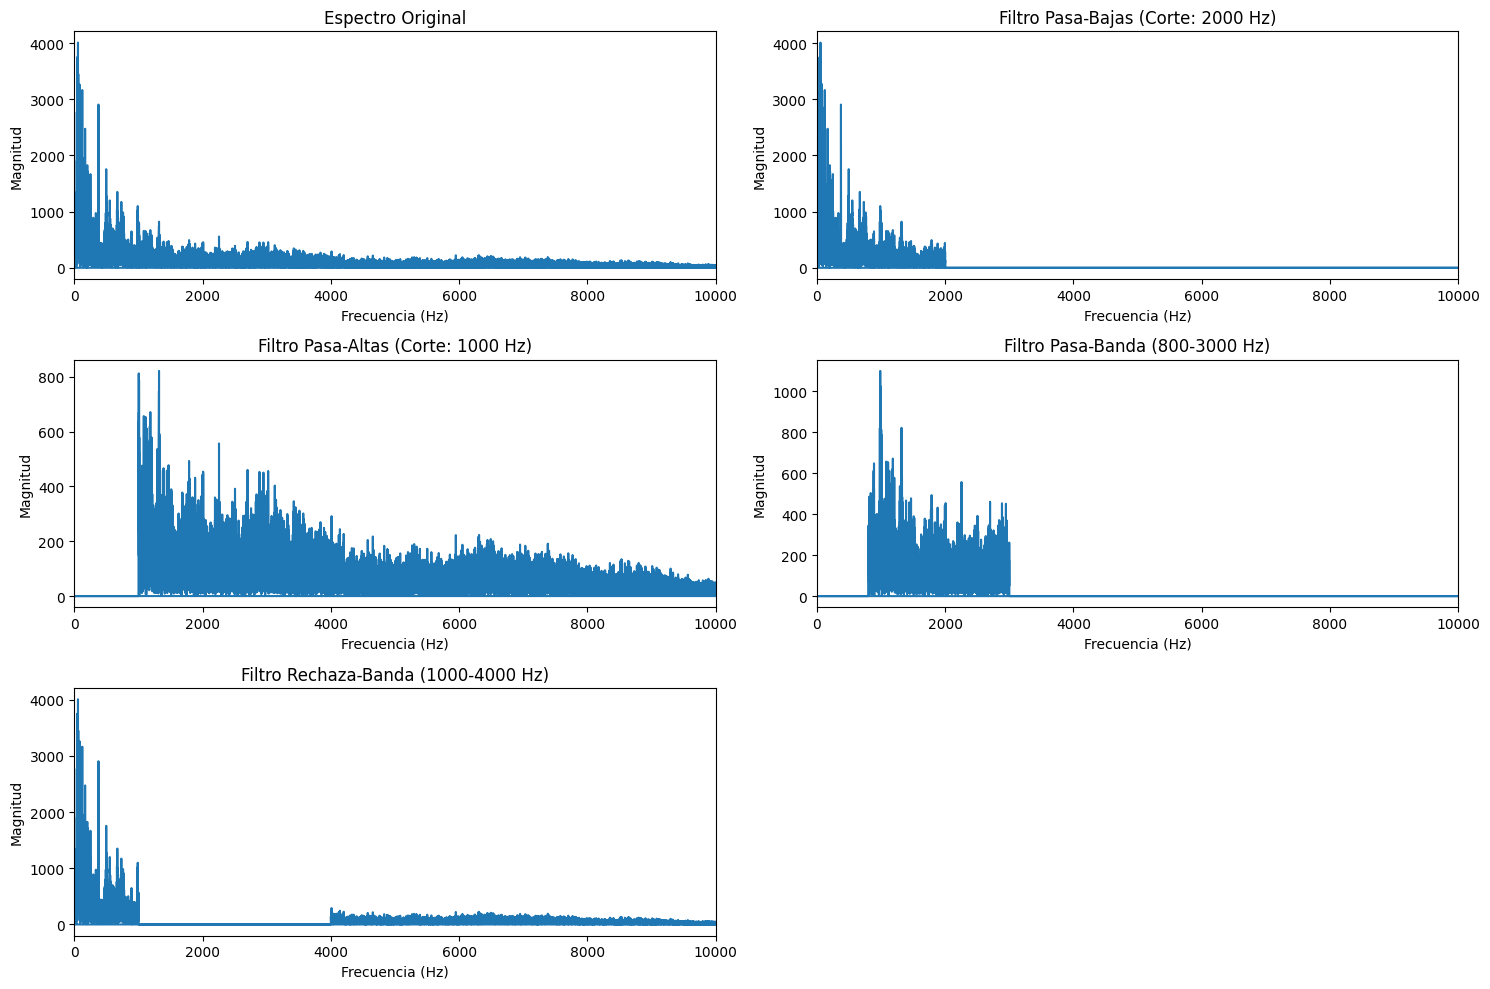

Archivo guardado: fiesta_pasabajas.wav
Archivo guardado: fiesta_pasaaltas.wav
Archivo guardado: fiesta_pasabanda.wav
Archivo guardado: fiesta_rechazabanda.wav
Archivo guardado: fiesta_original_corte.wav


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# IMPORTS - Librerías

import os
import numpy as np
import librosa
from scipy.io.wavfile import write
from scipy.fft import fft, ifft, fftfreq
import matplotlib.pyplot as plt
# ═══════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN

# Asegurar que el archivo subido tenga este nombre exacto
AUDIO_FILENAME = 'fiesta_pagana.wav'

START_TIME_S = 1 * 60 + 48  # Minuto 1:48
DURATION_S = 5              # Duración 5 segundos
# ═══════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════
# FRECUENCIAS DE CORTE

CUTOFF_LOW = 2000
CUTOFF_HIGH = 1000
CUTOFF_BAND_L = 800
CUTOFF_BAND_H = 3000
CUTOFF_REJECT_L = 1000
CUTOFF_REJECT_H = 4000
# ═══════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════
# VERIFICACIÓN DE AUDIO

def verificar_archivo():
    if os.path.exists(AUDIO_FILENAME):
        print(f"Archivo '{AUDIO_FILENAME}' encontrado exitosamente.")
        return True
    else:
        print(f"ERROR: No se encuentra el archivo '{AUDIO_FILENAME}'.")
        print("PASO 1: Descargar la canción en tu computadora.")
        print(f"PASO 2: Renombrarla a '{AUDIO_FILENAME}'.")
        print("PASO 3: Arrastrarla a la carpeta de archivos de Colab (panel izquierdo).")
        return False
# ═══════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN

def plot_spectra(xf, yf_orig, yf_low, yf_high, yf_band, yf_reject, sr):
    print("Generando gráficas del espectro...")
    plt.figure(figsize=(15, 10))

    max_freq_to_plot = min(sr / 2, 10000)

    # 1. Espectro Original
    plt.subplot(3, 2, 1)
    plt.plot(xf, np.abs(yf_orig))
    plt.title('Espectro Original')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.xlim(0, max_freq_to_plot)

    # 2. Pasa-bajas
    plt.subplot(3, 2, 2)
    plt.plot(xf, np.abs(yf_low))
    plt.title(f'Filtro Pasa-Bajas (Corte: {CUTOFF_LOW} Hz)')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.xlim(0, max_freq_to_plot)

    # 3. Pasa-altas
    plt.subplot(3, 2, 3)
    plt.plot(xf, np.abs(yf_high))
    plt.title(f'Filtro Pasa-Altas (Corte: {CUTOFF_HIGH} Hz)')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.xlim(0, max_freq_to_plot)

    # 4. Pasa-banda
    plt.subplot(3, 2, 4)
    plt.plot(xf, np.abs(yf_band))
    plt.title(f'Filtro Pasa-Banda ({CUTOFF_BAND_L}-{CUTOFF_BAND_H} Hz)')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.xlim(0, max_freq_to_plot)

    # 5. Rechaza-banda
    plt.subplot(3, 2, 5)
    plt.plot(xf, np.abs(yf_reject))
    plt.title(f'Filtro Rechaza-Banda ({CUTOFF_REJECT_L}-{CUTOFF_REJECT_H} Hz)')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.xlim(0, max_freq_to_plot)

    plt.tight_layout()
    plt.show()
# ═══════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════
# PROCESAMIENTO Y FILTRADO

def filtrar_audio():
    # Carga de audio manual
    print(f"Cargando {DURATION_S}s de audio desde {START_TIME_S}s...")
    try:
        y, sr = librosa.load(
            AUDIO_FILENAME,
            sr=None,
            offset=START_TIME_S,
            duration=DURATION_S
        )
    except Exception as e:
        print(f"Error al leer el archivo de audio: {e}")
        return

    print(f"Audio cargado. Tasa de muestreo: {sr} Hz. Muestras: {len(y)}")

    # Transformada de Fourier
    N = len(y)
    yf = fft(y)
    xf = fftfreq(N, 1 / sr)

    # Copias para filtros
    yf_low = np.copy(yf)
    yf_high = np.copy(yf)
    yf_band = np.copy(yf)
    yf_reject = np.copy(yf)

    # Aplicación de filtros (Haciendo cero las frecuencias no deseadas)
    yf_low[np.abs(xf) > CUTOFF_LOW] = 0
    yf_high[np.abs(xf) < CUTOFF_HIGH] = 0
    yf_band[(np.abs(xf) < CUTOFF_BAND_L) | (np.abs(xf) > CUTOFF_BAND_H)] = 0
    yf_reject[(np.abs(xf) > CUTOFF_REJECT_L) & (np.abs(xf) < CUTOFF_REJECT_H)] = 0

    print("Filtros aplicados en el dominio de la frecuencia.")

    # Gráficas
    plot_spectra(xf, yf, yf_low, yf_high, yf_band, yf_reject, sr)

    # Transformada Inversa (iFFT) para recuperar el audio filtrado
    y_low = np.real(ifft(yf_low))
    y_high = np.real(ifft(yf_high))
    y_band = np.real(ifft(yf_band))
    y_reject = np.real(ifft(yf_reject))

    # Guardado de archivos
    def guardar_wav(filename, y_signal, sr):
        max_val = np.max(np.abs(y_signal))
        if max_val > 0:
            y_norm = y_signal / max_val
        else:
            y_norm = y_signal
        y_int16 = np.int16(y_norm * 32767)
        write(filename, sr, y_int16)
        print(f"Archivo guardado: {filename}")

    guardar_wav('fiesta_pasabajas.wav', y_low, sr)
    guardar_wav('fiesta_pasaaltas.wav', y_high, sr)
    guardar_wav('fiesta_pasabanda.wav', y_band, sr)
    guardar_wav('fiesta_rechazabanda.wav', y_reject, sr)
    guardar_wav('fiesta_original_corte.wav', y, sr)
# ═══════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════
# EJECUCIÓN PRINCIPAL

if __name__ == "__main__":
    # Solo procedemos si el archivo existe
    if verificar_archivo():
      filtrar_audio()
# ═══════════════════════════════════════════════════════════════════════════

# Simulación modulación por amplitud con detección coherente (AM) en Python

- La modulación se entiende como el proceso mediante el cual una señal mensaje se adecuda al medio de transmisión.

- En radiofrecuencia, la modulación básica consiste en manipular la amplitud de una señal de alta frecuencia, denominada portadora, respecto al mensaje.

- Dicho proceso se conoce como modulación por amplitud. Para más detalle ver [modulación AM](https://en.wikipedia.org/wiki/Amplitude_modulation).

- Se requiere entonces de una portadora (carrier) senoidal/cosenoidal:

$$c(t)=A_c\sin(2\pi F_c t)$$

- Para ilustrar el proceso, se trabaja con un mensaje tipo sen/cos:

$$m(t) = A_m \cos(2\pi F_m t)$$

- La modulación AM puede calibrarse en términos del índice de modulación:

$$I_m = \frac{Peak\{|m(t)|\}}{A_c}$$

 donde $Peak\{|m(t)|\}$ es el valor pico (máximo) de $|m(t)|$.



In [ ]:
# Aseguramos que las librerías necesarias estén listas
import librosa
import numpy as np

# Usamos las mismas variables de configuración que teníamos arriba
AUDIO_FILENAME = 'fiesta_pagana.wav'
START_TIME_S = 1 * 60 + 48
DURATION_S = 5

# Cargamos el audio aqui para que quede guardado en las variables globales 'y' y 'sr'
try:
    y, sr = librosa.load(
        AUDIO_FILENAME,
        sr=None,
        offset=START_TIME_S,
        duration=DURATION_S
    )
    print(f"Audio cargado en memoria global.")
    print(f"   - Tasa de muestreo (sr): {sr} Hz")
    print(f"   - Muestras totales: {len(y)}")
except Exception as e:
    print(f"Error: {e}. Asegúrate de haber subido el archivo .wav")

Audio cargado en memoria global.
   - Tasa de muestreo (sr): 44100 Hz
   - Muestras totales: 220500


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
#Frecuencia portadora y muestreo

Fs = sr  # La frecuencia de muestreo viene del audio cargado

Fc = 10000 # Aumentamos a 10 kHz para que soporte el audio la portadora

# Definimos el vector de tiempo basado en la duración del audio cargado
t = np.linspace(0, len(y)/Fs, len(y))

# Asignamos el audio cargado como el mensaje mensaje m(t)
m = y

# Índice de modulación (puedes ajustarlo, 0.8 es buen valor)
Im = 0.8

# Calculamos la Amplitud de portadora necesaria
Ac = np.max(np.abs(m))/Im

# Generamos la Portadora c(t) = Ac * cos(2*pi*Fc*t)
c = Ac * np.cos(2 * np.pi * Fc * t)

print(f"Amplitud Portadora (Ac): {Ac}")

Amplitud Portadora (Ac): 1.2271308898925781


- Se grafican las señales mensaje y portadora:

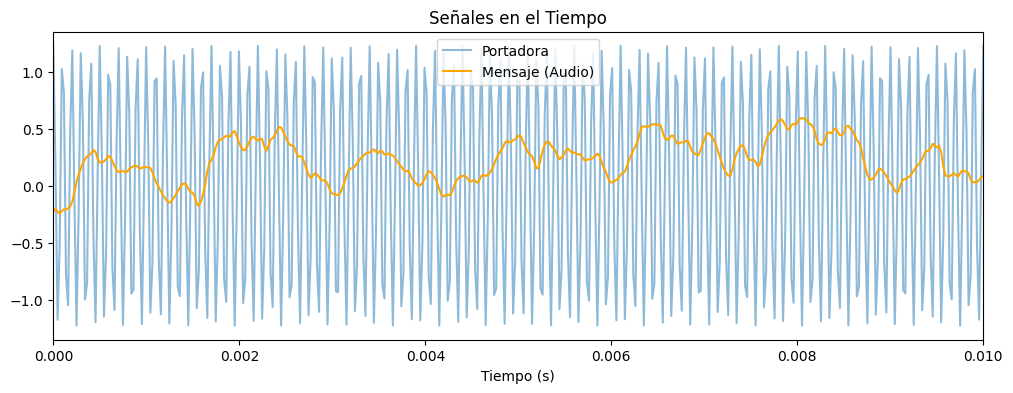

In [ ]:
# Se grafican las señales mensaje (Audio) y portadora:
plt.figure(figsize=(12, 4)) # Hacemos la figura un poco más ancha
plt.plot(t, c, label='Portadora', alpha=0.5) # alpha para transparencia
plt.plot(t, m, label='Mensaje (Audio)', color='orange')
plt.legend()
plt.title("Señales en el Tiempo")
plt.xlabel("Tiempo (s)")
plt.xlim(0, 0.01) # Hacemos zoom a una fracción pequeña de segundo para ver las ondas
plt.show()

- La señal a transmitir, señal modulada, en AM se cálcula como:

$$y(t)= \left(1+\frac{m(t)}{A_c}\right)c(t)$$

In [ ]:
y_mod = (1 + m/Ac) * c #señal modulada en AM

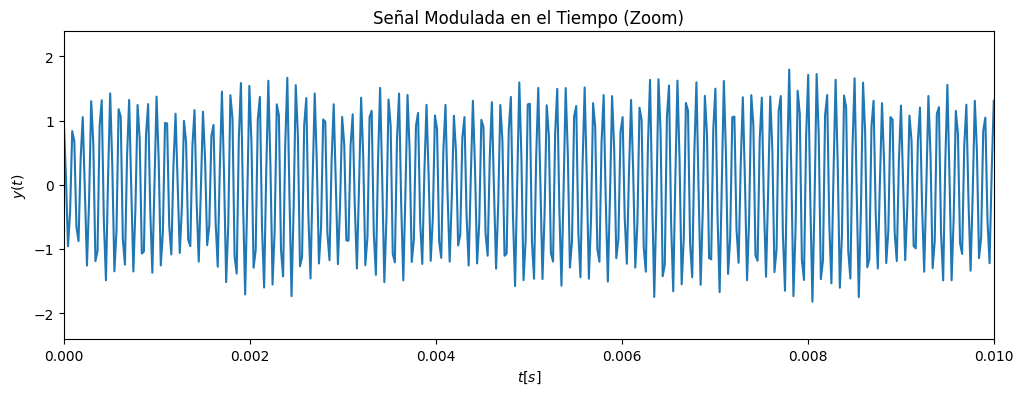

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(t, y_mod)
plt.title("Señal Modulada en el Tiempo (Zoom)")
plt.xlabel('$t [s]$')
plt.ylabel('$y(t)$')
plt.xlim(0, 0.01) # Zoom para ver la forma de onda
plt.show()

- A continuación, se presenta el espectro de la señal mensaje, portadora y modulada.

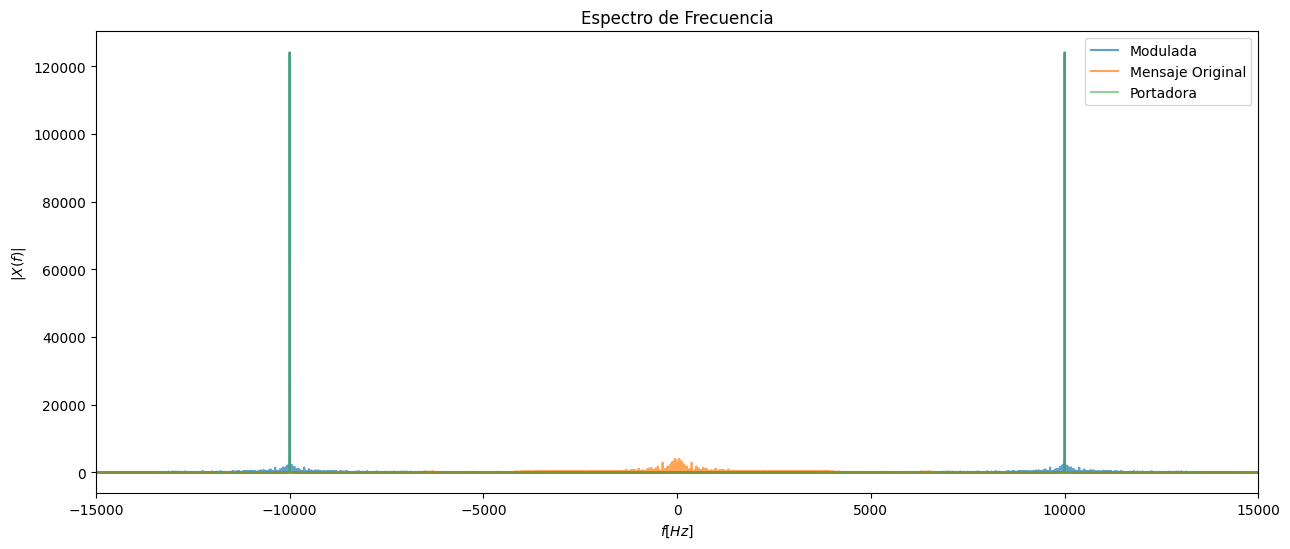

In [ ]:
# Transformada de Fourier de cada etapa
Xfc = np.fft.fft(c)
Xfm = np.fft.fft(m)
Xfy = np.fft.fft(y_mod)

# Eje de frecuencias
vfre = np.fft.fftfreq(len(c), 1/Fs)

# Gráfica
plt.figure(figsize=(15, 6))
plt.plot(vfre, abs(Xfy), label='Modulada', alpha=0.7)
plt.plot(vfre, abs(Xfm), label='Mensaje Original', alpha=0.7)
plt.plot(vfre, abs(Xfc), label='Portadora', alpha=0.5)
plt.legend()
plt.title("Espectro de Frecuencia")
plt.xlabel('$f [Hz]$')
plt.ylabel('$|X(f)|$')
# Limitamos el eje X para ver mejor
plt.xlim(-15000, 15000)
plt.show()

In [ ]:
#Xfc = np.fft.rfft(c)
#Xfm = np.fft.rfft(m)
#Xfy = np.fft.rfft(y)

#vfre = np.fft.rfftfreq(len(c),1/Fs)

#plt.plot(vfre,abs(Xfy),label='modulado')
#plt.plot(vfre,abs(Xfm),label='mensaje')
#plt.plot(vfre,abs(Xfc),label='portadora')
#plt.legend()
#plt.xlabel('$f [Hz]$')
#plt.ylabel('$|X(f)|$')
#plt.ylim([min(abs(Xfm)), 1.1*max(abs(Xfm))])
#plt.show()

In [ ]:
# Etapa del Mezclador: Multiplicar recibida por portadora local (coseno)
# d(t) = y(t) * cos(2*pi*Fc*t) -> Usamos 'c' que ya tiene el coseno
# Para ser exactos con el diagrama, el oscilador local suele tener amplitud 1 o 2, pero usar 'c' (que tiene amplitud Ac) solo cambia la escala final.
d = y_mod * np.cos(2 * np.pi * Fc * t)

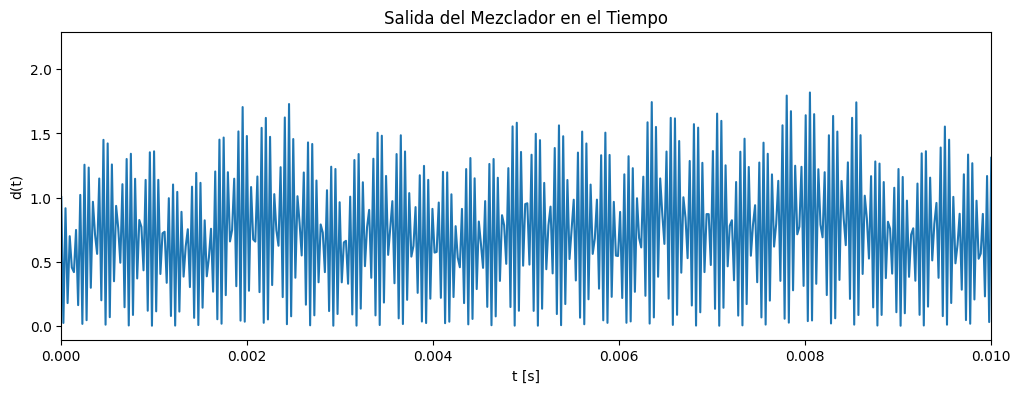

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(t, d)
plt.title("Salida del Mezclador en el Tiempo")
plt.xlabel('t [s]')
plt.ylabel('d(t)')
plt.xlim(0, 0.01) # Zoom
plt.show()

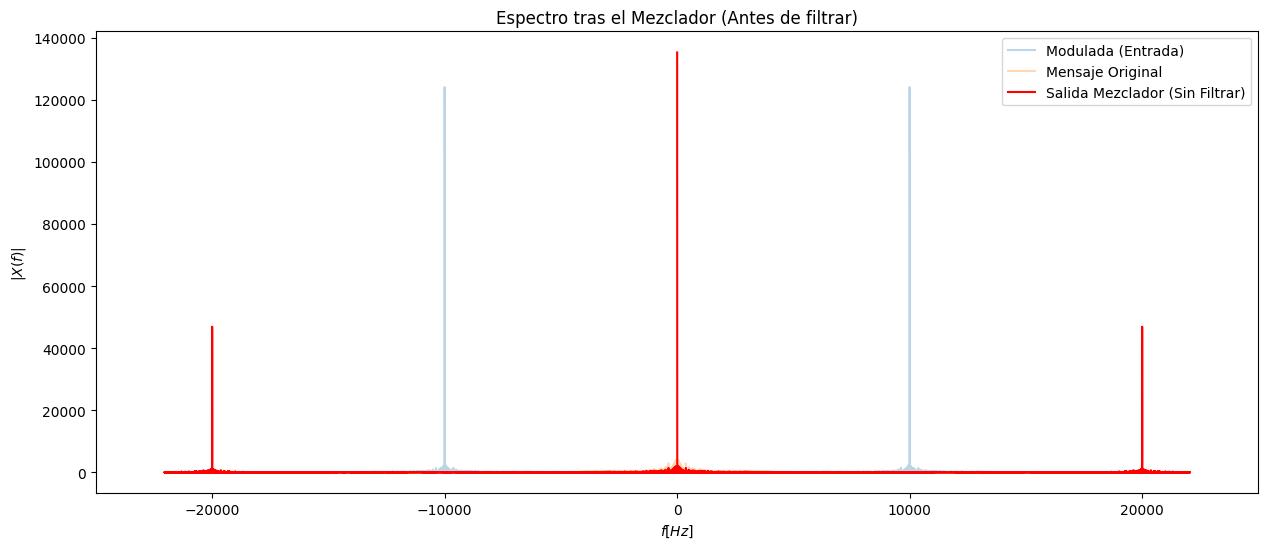

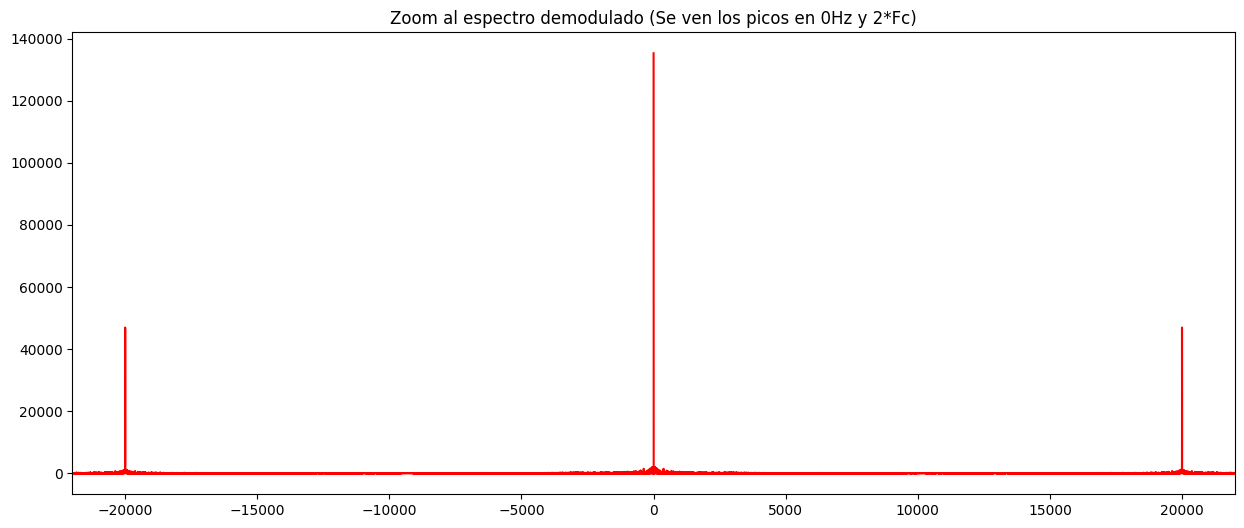

In [ ]:
# Transformada de la señal mezclada
Xfd = np.fft.fft(d)

# Recalculamos vfre por seguridad (aunque ya existe)
vfre = np.fft.fftfreq(len(c), 1/Fs)

plt.figure(figsize=(15, 6))
plt.plot(vfre, abs(Xfy), label='Modulada (Entrada)', alpha=0.3)
plt.plot(vfre, abs(Xfm), label='Mensaje Original', alpha=0.3)
# Xfd es la señal demodulada antes del filtro (tendrá componentes en alta frecuencia)
plt.plot(vfre, abs(Xfd), label='Salida Mezclador (Sin Filtrar)', c='r')

plt.legend()
plt.title("Espectro tras el Mezclador (Antes de filtrar)")
plt.xlabel('$f [Hz]$')
plt.ylabel('$|X(f)|$')
plt.xlim(-25000, 25000) # Vemos hasta 25k para ver los armónicos
plt.show()

# Zoom en la parte roja
plt.figure(figsize=(15, 6))
plt.plot(vfre, abs(Xfd), label='Salida Mezclador', c='r')
plt.title("Zoom al espectro demodulado (Se ven los picos en 0Hz y 2*Fc)")
plt.xlim(-22000, 22000)
plt.show()

In [ ]:
Xfd.shape

(220500,)

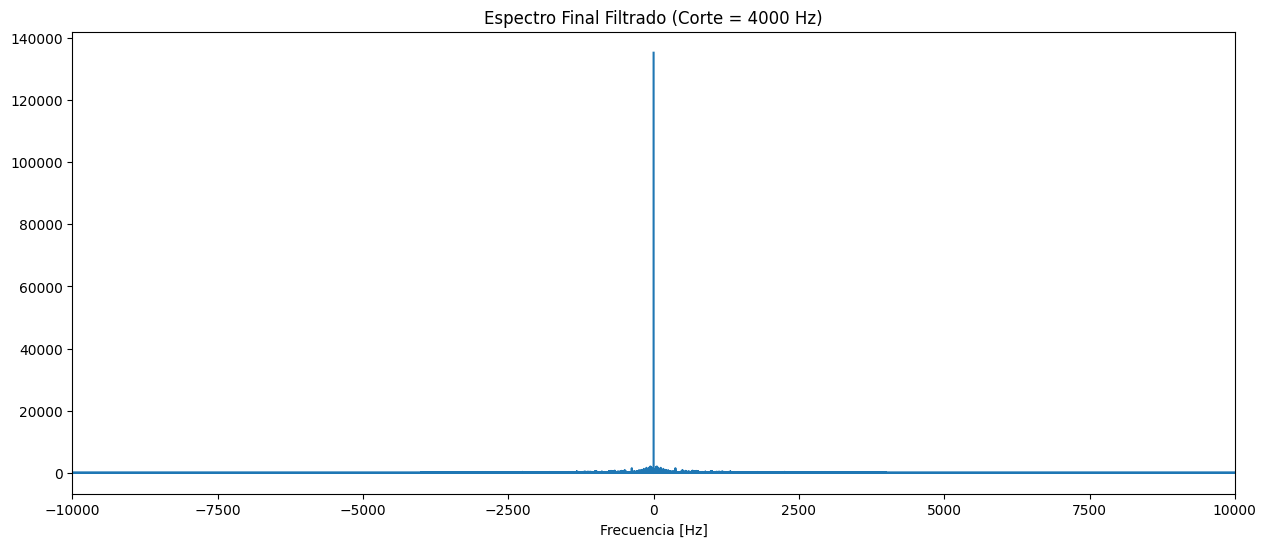

In [ ]:
# FILTRO PASA BAJAS IDEAL EN FRECUENCIA
# Queremos quedarnos solo con lo que está cerca de 0 Hz y eliminar lo que está en 2*Fc (20000Hz)

f_corte = 4000 # Frecuencia de corte en Hz (ajustable según el audio)

# Crear máscara: 1 si la frecuencia es menor al corte, 0 si es mayor (filtro ideal)
# np.abs se usa porque las frecuencias en FFT van de negativos a positivos
ind = ~(np.abs(vfre) < f_corte)

# Aplicar filtro: Hacemos cero todo lo que esté fuera del rango de corte
Xfd[ind] = 0

plt.figure(figsize=(15, 6))
plt.plot(vfre, abs(Xfd))
plt.title(f"Espectro Final Filtrado (Corte = {f_corte} Hz)")
plt.xlabel("Frecuencia [Hz]")
plt.xlim(-10000, 10000)
plt.show()

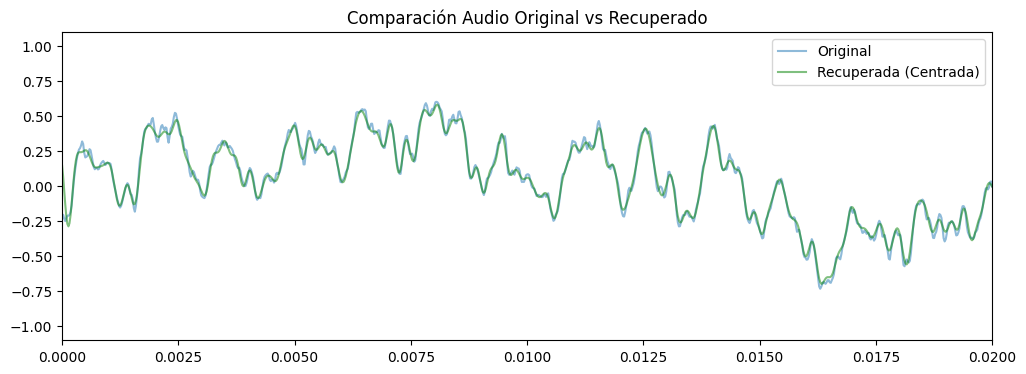

Audio demodulado guardado como 'audio_demodulado.wav'


In [ ]:
# Transformada inversa para volver al tiempo
mr = np.real(np.fft.ifft(Xfd))

# En la teoría se escala por 2/A1, aquí normalizamos para escuchar bien.
mr = mr - np.mean(mr)

mr = mr / np.max(np.abs(mr))

# Graficar comparación
plt.figure(figsize=(12, 4))
plt.plot(t, m/np.max(np.abs(m)), label='Original', alpha=0.5)
plt.plot(t, mr, label='Recuperada (Centrada)', color='green', alpha=0.5)
plt.title("Comparación Audio Original vs Recuperado")
plt.legend()
plt.xlim(0, 0.02) # Zoom
plt.show()

# Guardar el audio resultante para escucharlo
write('audio_demodulado.wav', Fs, np.int16(mr * 32767))
print("Audio demodulado guardado como 'audio_demodulado.wav'")

## Código unido

Archivo 'fiesta_pagana.wav' encontrado.
Cargando audio...
Generando gráficas de las 4 etapas...


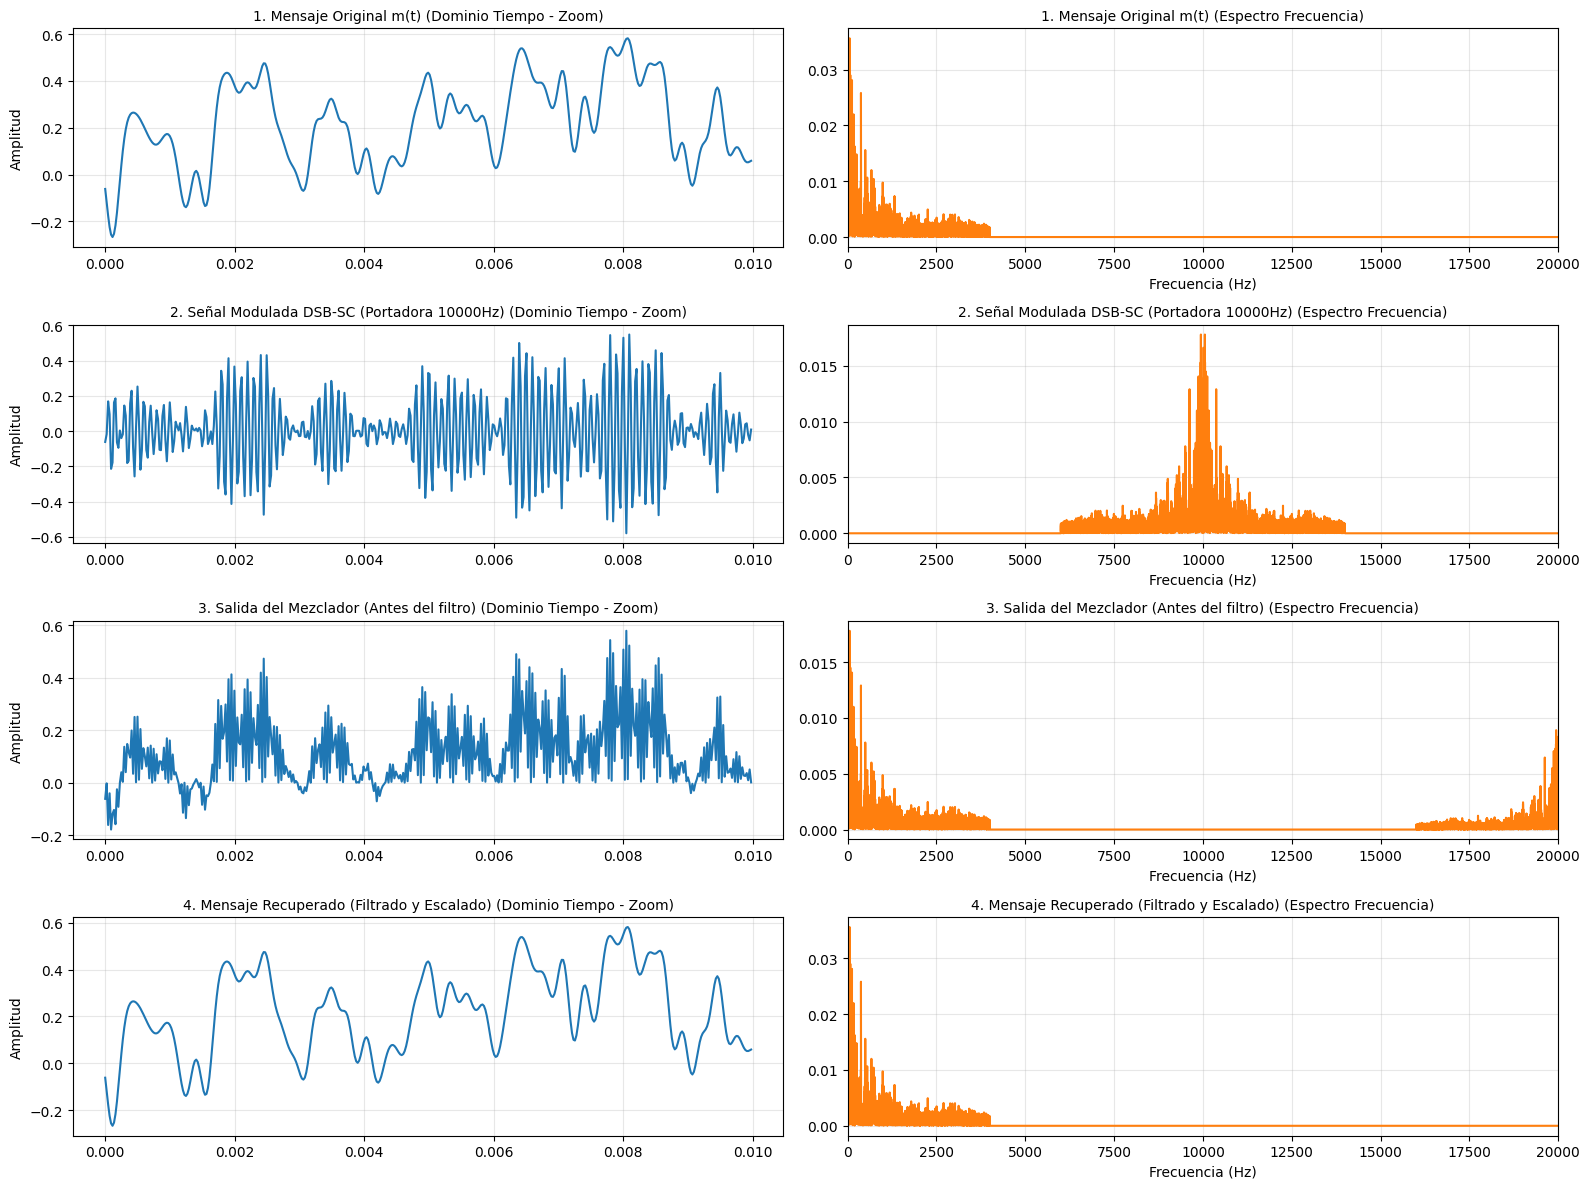

Guardado: 1_mensaje_original.wav
Guardado: 2_modulada_dsb_sc.wav
Guardado: 3_salida_mezclador.wav
Guardado: 4_recuperada_final.wav
Listo!


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# IMPORTS - Librerías

import os
import numpy as np
import librosa
from scipy.io.wavfile import write
from scipy.fft import fft, ifft, fftfreq, fftshift
import matplotlib.pyplot as plt
# ═══════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DEL SISTEMA DSB-SC

AUDIO_FILENAME = 'fiesta_pagana.wav'
START_TIME_S = 108          # Minuto 1:48 (108 segundos)
DURATION_S = 5              # Duración 5 segundos

# Parámetros de Modulación
CARRIER_FREQ = 10000        # f0: Frecuencia de portadora (10 kHz)
AUDIO_BW = 4000             # Ancho de banda del mensaje (Limitamos a 4kHz para evitar Aliasing)
# ═══════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════
# HERRAMIENTAS AUXILIARES

def verificar_archivo():
    if os.path.exists(AUDIO_FILENAME):
        print(f"Archivo '{AUDIO_FILENAME}' encontrado.")
        return True
    else:
        print(f"ERROR: No se encuentra '{AUDIO_FILENAME}'. Subirlo al entorno.")
        return False

def guardar_wav(filename, signal, sr):
    # Normalizar para evitar saturación al guardar
    max_val = np.max(np.abs(signal))
    if max_val > 0:
        signal_norm = signal / max_val
    else:
        signal_norm = signal
    write(filename, sr, np.int16(signal_norm * 32767))
    print(f"Guardado: {filename}")
# ═══════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN (TIEMPO Y FRECUENCIA)

def graficar_etapas(t, signals, titulos, sr):
    n_etapas = len(signals)
    plt.figure(figsize=(16, 12))

    for i, (sig, titulo) in enumerate(zip(signals, titulos)):
        # 1. Dominio del Tiempo (Zoom a un fragmento pequeño para ver la onda)
        plt.subplot(n_etapas, 2, 2*i + 1)
        # Graficamos solo 0.01 segundos para ver la forma de onda
        zoom_samples = int(0.01 * sr)
        plt.plot(t[:zoom_samples], sig[:zoom_samples], color='tab:blue')
        plt.title(f"{titulo} (Dominio Tiempo - Zoom)", fontsize=10)
        plt.ylabel("Amplitud")
        plt.grid(alpha=0.3)

        # 2. Dominio de la Frecuencia (Espectro)
        plt.subplot(n_etapas, 2, 2*i + 2)
        N = len(sig)
        yf = fft(sig)
        xf = fftfreq(N, 1 / sr)

        # Usamos fftshift para centrar el 0 Hz visualmente si quisieramos,
        # pero aquí mostramos la parte positiva estándar de 0 a sr/2
        half_N = N // 2
        plt.plot(xf[:half_N], 2.0/N * np.abs(yf[:half_N]), color='tab:orange')
        plt.title(f"{titulo} (Espectro Frecuencia)", fontsize=10)
        plt.xlabel("Frecuencia (Hz)")
        plt.xlim(0, 20000) # Ver hasta 20kHz
        plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
# ═══════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════
# PROCESO PRINCIPAL: MODULACIÓN Y DEMODULACIÓN

def procesar_dsp():
    # 1. CARGAR AUDIO
    print(f"Cargando audio...")
    y, sr = librosa.load(AUDIO_FILENAME, sr=None, offset=START_TIME_S, duration=DURATION_S)

    # Pre-filtrado: Limitamos el audio a 4kHz para que quepa en la portadora sin aliasing
    N = len(y)
    yf_orig = fft(y)
    xf = fftfreq(N, 1/sr)
    mask_bw = np.abs(xf) < AUDIO_BW
    y = np.real(ifft(yf_orig * mask_bw))
    # Normalizamos el mensaje entre -1 y 1
    y = y / np.max(np.abs(y))

    # Vector de tiempo
    t = np.linspace(0, DURATION_S, N, endpoint=False)

    # Definimos la señal portadora (Oscilador Local): cos(2*pi*f0*t)
    # Asumimos Theta0 = 0
    carrier = np.cos(2 * np.pi * CARRIER_FREQ * t)
# ═══════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════
    # ETAPA 1: MODULACIÓN (Entrada DSB-SC)
    # x(t) = m(t) * cos(wc*t)

    x_t = y * carrier
# ═══════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════
    # ETAPA 2: MEZCLADOR (DEMODULACIÓN SÍNCRONA)
    # y_mix(t) = x(t) * cos(wc*t)
    # Esto genera componentes en Banda Base y en 2*f0

    y_mix = x_t * carrier
# ═══════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════
    # ETAPA 3: FILTRO PASA BAJAS (Implementación con FFT)
    # Filtramos todo lo que esté por encima del ancho de banda del audio

    Y_f = fft(y_mix)

    # Crear máscara ideal (1 si freq < corte, 0 si freq > corte)
    # El corte debe ser mayor que el audio (4k) pero menor que 2*f0 (20k)
    # Usamos 5000 Hz como corte seguro.
    cutoff_lpf = AUDIO_BW + 500
    mask_lpf = np.abs(xf) < cutoff_lpf

    Z_f = Y_f * mask_lpf # Aplicamos el filtro en frecuencia (Multiplicación)

    z_t = np.real(ifft(Z_f)) # Volvemos al tiempo
# ═══════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════
    # ETAPA 4: ESCALADO DE AMPLITUD
    # Recuperamos la amplitud original multiplicando por 2

    m_recovered = z_t * 2
# ═══════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════
    # RESULTADOS

    print("Generando gráficas de las 4 etapas...")
    signals = [y, x_t, y_mix, m_recovered]
    titulos = [
        "1. Mensaje Original m(t)",
        f"2. Señal Modulada DSB-SC (Portadora {CARRIER_FREQ}Hz)",
        "3. Salida del Mezclador (Antes del filtro)",
        "4. Mensaje Recuperado (Filtrado y Escalado)"
    ]

    graficar_etapas(t, signals, titulos, sr)

    # Guardar audios para escuchar
    guardar_wav('1_mensaje_original.wav', y, sr)
    guardar_wav('2_modulada_dsb_sc.wav', x_t, sr) # Sonará agudo y raro
    guardar_wav('3_salida_mezclador.wav', y_mix, sr) # Sonará con ruido de alta frec
    guardar_wav('4_recuperada_final.wav', m_recovered, sr) # Debería sonar bien
    print("Listo!")
# ═══════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════
# EJECUCIÓN

if __name__ == "__main__":
    if verificar_archivo():
      procesar_dsp()
# ═══════════════════════════════════════════════════════════════════════════